## Analyzing false positives in branchwater containment search due to k-mer size of 21

With reference to:

Ondov, B., Starrett, G., Sappington, A. et al. Mash Screen: high-throughput sequence containment estimation for genome discovery. Genome Biol 20, 232 (2019). https://doi.org/10.1186/s13059-019-1841-x

We can calculate the probability of a random *k*-mer occuring in a mixture using **Equation 5** from Ondov et al., 2019, by calculating the expected containment of A within B. More formally, the authors say: "Because the containment index does not depend on the size of the larger set, the expected containment of one random set, A, within another, B, is simply the probability *r* that a random *k*-mer, K, appears in B." If $n_B$ is the size of the mixture B, then this probability $r$ is:

$$
r = P(K \in B) = 4^{-k} n_B
$$

For the sourmash branchwater implementation of hashing, we divide the number of k-mers by a factor of 2 to account for canonical hashing, so the revised equation is:


$$
r' = P(K \in B) = 2 (4^{-k}) n_B
$$


## Plotting containment vs mixture size

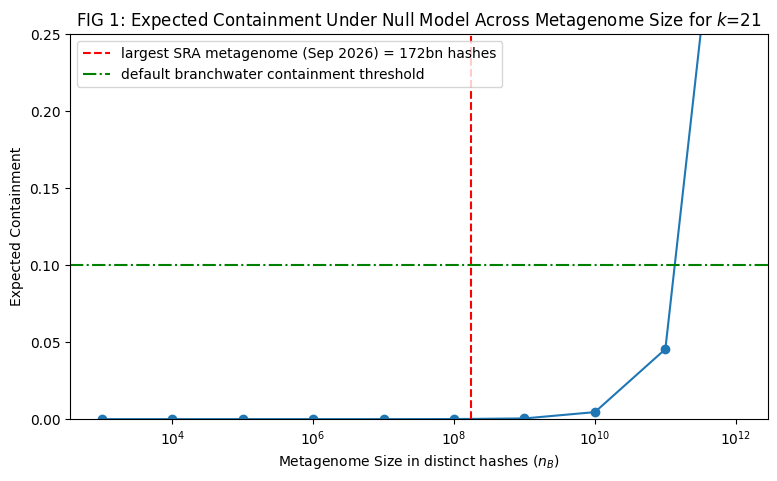

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Number of distinct k-mers in mixture B
nB_values = np.array([10**i for i in range(3, 13)])

k = 21

# adjust by factor of two for canonical hashing
probabilities = 2 * (4 ** (-k)) * nB_values

plt.figure(figsize=(9, 5))

plt.plot(
    nB_values,
    probabilities,
    marker="o"
)

plt.axvline(172806396, color='r', linestyle='--',
            label='largest SRA metagenome (Sep 2026) = 172bn hashes')
plt.axhline(0.1, color='g', linestyle='-.',
            label='default branchwater containment threshold')

plt.xscale("log")
plt.ylim(0, 0.25)
plt.xlabel("Metagenome Size in distinct hashes ($n_B$)")
plt.ylabel("Expected Containment")
plt.title("FIG 1: Expected Containment Under Null Model Across Metagenome Size for $k$=21")
plt.legend(loc='upper left')

plt.show()

## Simulating Null Model: Observed vs. Predicted Results in Branchwater

We created 4 sketches at with random 21-mers scaled=1000 of sizes 100, 1_000, 5_000, and 10_000, matching the normal size range of bacterial genome queries, and searched them against 3,000 metagenomes chosen randomly from across the SRA.

The  results match the null model; variability at small sketch sizes is due to the variability in hashing small sketches. 

Unique queries: 4
Metagenomes: 2,822
Expected Comparisons: 11,288
Final Comparisons: 11,288
Pairs Added with Zero Containment: 9,887


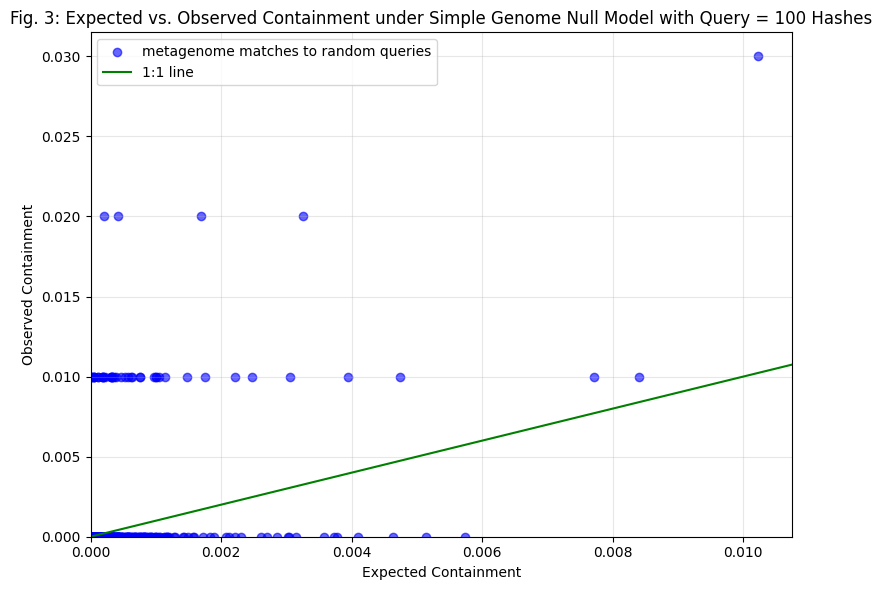

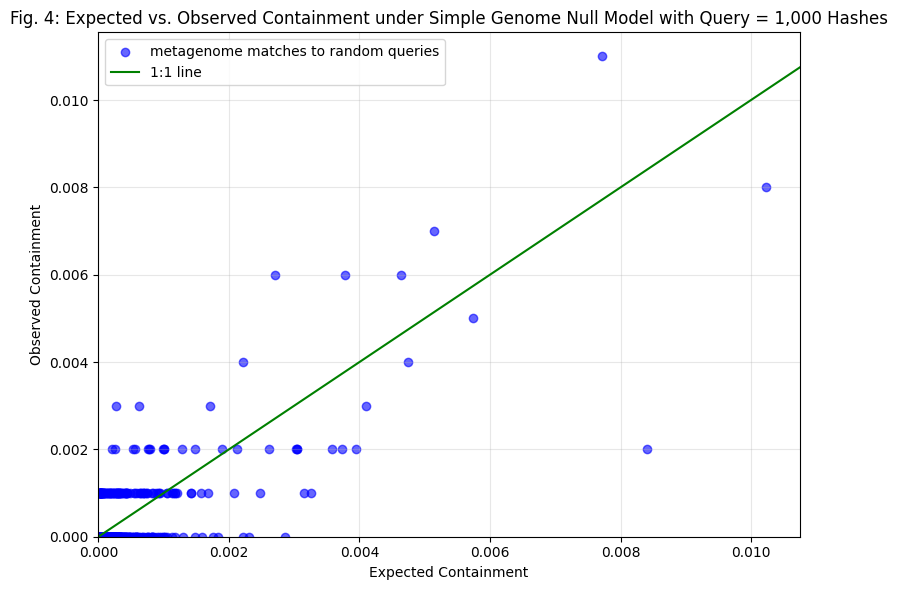

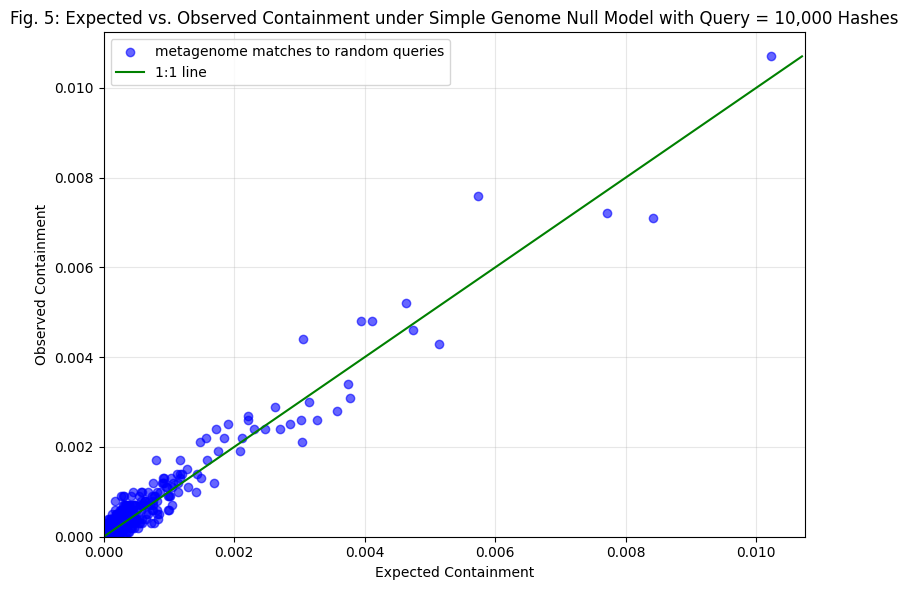

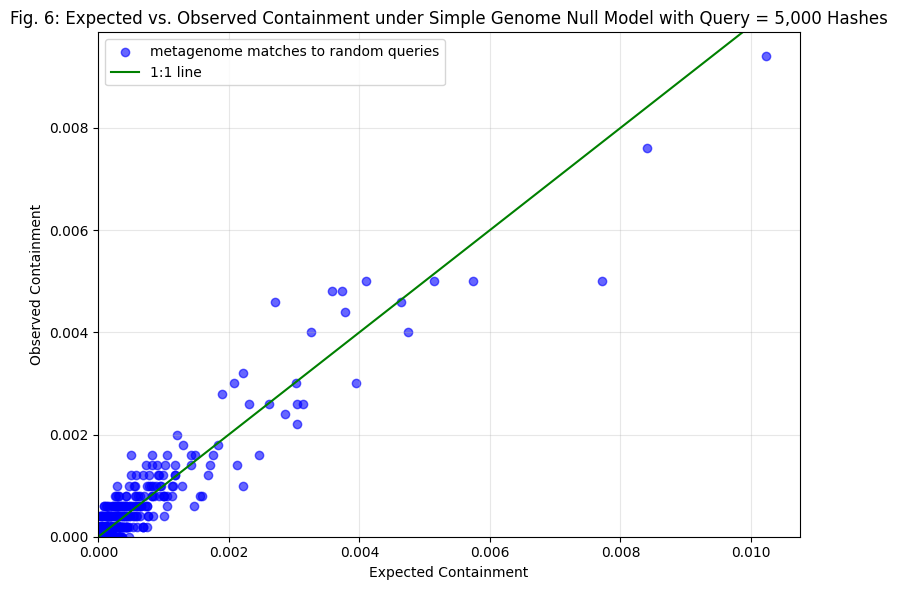

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import polars as pl

wort_df = pl.read_csv(f"wort-false-positive-subset-3000-details.csv")
results_df = pl.read_csv(f"false-positive-subset-3000-results.csv")

# standardize the query column name.
if "query" not in results_df.columns:
    results_df = results_df.rename({"query_name": "query"})

# identify the unique queries represented in the results.
queries_df = results_df.select("query").unique()
n_queries = queries_df.height
expected_comparisons = n_queries * wort_df.height

# create every possible query–metagenome pair.
all_pairs = queries_df.join(
    wort_df.rename({"name": "match_name"}),
    how="cross",
)

# preserve whether a pair was actually present in the results file.
results_df = results_df.with_columns(
    pl.lit(True).alias("reported_result")
)

# attach existing results; retain pairs with no reported match.
combined_df = (
    all_pairs
    .join(
        results_df,
        on=["query", "match_name"],
        how="left",
        suffix="_result",
        validate="1:1",
    )
    .with_columns(
        pl.col("containment").fill_null(0.0),
        pl.col("intersect_hashes").fill_null(0),
        pl.col("reported_result").fill_null(False),
    )
    .sort(["query", "n_hashes"])
)

n_added = combined_df.filter(~pl.col("reported_result")).height

print(f"Unique queries: {n_queries:,}")
print(f"Metagenomes: {wort_df.height:,}")
print(f"Expected Comparisons: {expected_comparisons:,}")
print(f"Final Comparisons: {combined_df.height:,}")
print(f"Pairs Added with Zero Containment: {n_added:,}")

# estimate containment from the number of distinct k-mers before sketching.
combined_df = (combined_df
    .with_columns(
        (pl.col("n_hashes").cast(pl.Float64) *
         pl.col("scaled")).alias("nB")
    ).with_columns(((4.0 ** (-21)) * 2 * pl.col("nB")).alias("expected_containment"))
)

CURR_FIG_NUM = 2

for query in sorted(combined_df["query"].unique().to_list()):
    CURR_FIG_NUM = CURR_FIG_NUM + 1
    query_dict = {
        query: int(query.split("=")[1])
        for query in combined_df["query"].unique().to_list()
    }
    
    subset = combined_df.filter(pl.col("query") == query)

    x = subset["expected_containment"].to_numpy()
    y = subset["containment"].to_numpy()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(x, y, alpha=0.6, color='b',
               label='metagenome matches to random queries')

    ax.set_xlabel("Expected Containment")
    ax.set_ylabel("Observed Containment")
    ax.set_title(f"Fig. {CURR_FIG_NUM}: Expected vs. Observed Containment under Simple Genome Null Model with Query = {query_dict[query]:,} Hashes")
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

    plotmax = max(max(x), max(y))
    ax.plot([0, plotmax], [0, plotmax], 'g-', label='1:1 line')

    ax.legend()
    plt.tight_layout()
    plt.show()

## Concluding thoughts on containment false positives at k=21

For sufficiently large queries (1000 hashes ~ 1 million k-mers and above), matches are well below the default threshold in branchwater.